# Quantium Virtual Internship - Retail Strategy and Analytics - Task 2

### Load required libraries and datasets

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import re
from scipy import stats

In [2]:
store_data=pd.read_csv('QVI_data.csv')

In [3]:
store_data.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [4]:
store_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   LYLTY_CARD_NBR    264834 non-null  int64  
 1   DATE              264834 non-null  str    
 2   STORE_NBR         264834 non-null  int64  
 3   TXN_ID            264834 non-null  int64  
 4   PROD_NBR          264834 non-null  int64  
 5   PROD_NAME         264834 non-null  str    
 6   PROD_QTY          264834 non-null  int64  
 7   TOT_SALES         264834 non-null  float64
 8   PACK_SIZE         264834 non-null  int64  
 9   BRAND             264834 non-null  str    
 10  LIFESTAGE         264834 non-null  str    
 11  PREMIUM_CUSTOMER  264834 non-null  str    
dtypes: float64(1), int64(6), str(5)
memory usage: 24.2 MB


## Select control stores

In [5]:
trial_store=store_data[store_data['STORE_NBR'].isin([77,86,88])].copy()

In [6]:
print(trial_store)

        LYLTY_CARD_NBR        DATE  STORE_NBR  TXN_ID  PROD_NBR  \
73365            77000  2019-03-28         77   74911        18   
73366            77000  2019-04-13         77   74912        69   
73367            77000  2018-09-26         77   74910        36   
73368            77001  2019-02-27         77   74913         7   
73369            77001  2019-01-21         77   74914         9   
...                ...         ...        ...     ...       ...   
264829         2370701  2018-12-08         88  240378        24   
264830         2370751  2018-10-01         88  240394        60   
264831         2370961  2018-10-24         88  240480        70   
264832         2370961  2018-10-27         88  240481        65   
264833         2373711  2018-12-14         88  241815        16   

                                       PROD_NAME  PROD_QTY  TOT_SALES  \
73365             Cheetos Chs & Bacon Balls 190g         1        3.3   
73366     Smiths Chip Thinly  S/Cream&Onion 175g 

### The client has selected store numbers 77, 86 and 88 as trial stores and want control stores to be established stores that are operational for the entire observation period.We would want to match trial stores to control stores that are similar to the trialstore prior to the trial period of Feb 2019 in terms of :- Monthly overall sales revenue- Monthly number of customers- Monthly number of transactions per customerLet's first create the metrics of interest and filter to stores that are present throughout the pre-trial period.


In [7]:
store_data["DATE"]= pd.to_datetime(store_data["DATE"])
store_data["YEARMONTH"] =store_data["DATE"].dt.strftime("%Y%m").astype(int)

# ── 2. Monthly metrics ────────────────────────────────────────────────────────
store_monthly = (
    store_data.groupby(["STORE_NBR", "YEARMONTH"])
    .agg(TOT_SALES=("TOT_SALES","sum"), nCustomers=("LYLTY_CARD_NBR","nunique"),
         nTxns=("TXN_ID","count"), totalChips=("PROD_QTY","sum"))
    .reset_index()
)
store_monthly["nTxnPerCust"]     = store_monthly["nTxns"]      / store_monthly["nCustomers"]
store_monthly["nChipsPerTxn"]    = store_monthly["totalChips"] / store_monthly["nTxns"]
store_monthly["avgPricePerUnit"] = store_monthly["TOT_SALES"]  / store_monthly["totalChips"]
store_monthly = store_monthly.sort_values(["STORE_NBR","YEARMONTH"]).reset_index(drop=True)

storesWithFullObs = (
    store_monthly.groupby("STORE_NBR")["YEARMONTH"]
    .nunique()
    .pipe(lambda x: x[x == 12].index)
)

preTrialMeasures = store_monthly[
    (store_monthly["YEARMONTH"] < 201902) &
    (store_monthly["STORE_NBR"].isin(storesWithFullObs))
].reset_index(drop=True)

# Verify
print(f"store_monthly shape    : {store_monthly.shape}")           # (3120, 10)
print(f"storesWithFullObs count: {len(storesWithFullObs)}")        # 260
print(f"preTrialMeasures shape : {preTrialMeasures.shape}")        # (1820, 10)
print(f"Unique stores          : {preTrialMeasures['STORE_NBR'].nunique()}")  # 260

# ── 4. Functions ──────────────────────────────────────────────────────────────
def calculateCorrelation(inputTable, metricCol, storeComparison):
    trial_series = inputTable[inputTable["STORE_NBR"]==storeComparison].set_index("YEARMONTH")[metricCol]
    results = []
    for store in inputTable["STORE_NBR"].unique():
        control_series = inputTable[inputTable["STORE_NBR"]==store].set_index("YEARMONTH")[metricCol]
        combined = pd.concat([trial_series.rename("trial"), control_series.rename("control")], axis=1).dropna()
        if len(combined) < 2: continue
        corr = combined.iloc[:,0].corr(combined.iloc[:,1])
        results.append({"Store1": storeComparison, "Store2": store, "corr_measure": round(corr,4)})
    return pd.DataFrame(results).sort_values("corr_measure", ascending=False).reset_index(drop=True)

def calculateMagnitudeDistance(inputTable, metricCol, storeComparison):
    trial_series = inputTable[inputTable["STORE_NBR"]==storeComparison].set_index("YEARMONTH")[metricCol]
    records = []
    for store in inputTable["STORE_NBR"].unique():
        control_series = inputTable[inputTable["STORE_NBR"]==store].set_index("YEARMONTH")[metricCol]
        combined = pd.concat([trial_series.rename("trial"), control_series.rename("control")], axis=1).dropna()
        for ym, row in combined.iterrows():
            records.append({"Store1": storeComparison, "Store2": store, "YEARMONTH": ym, "measure": abs(row["trial"]-row["control"])})
    calcDistTable = pd.DataFrame(records)
    minMaxDist = calcDistTable.groupby(["Store1","YEARMONTH"])["measure"].agg(minDist="min", maxDist="max").reset_index()
    distTable = calcDistTable.merge(minMaxDist, on=["Store1","YEARMONTH"])
    distTable["magnitudeMeasure"] = 1 - (distTable["measure"]-distTable["minDist"])/(distTable["maxDist"]-distTable["minDist"])
    return (distTable.groupby(["Store1","Store2"])["magnitudeMeasure"].mean().reset_index()
            .rename(columns={"magnitudeMeasure":"mag_measure"}).sort_values("mag_measure", ascending=False).reset_index(drop=True))

# ── 5. Store 86 control selection ─────────────────────────────────────────────
trial_store  = 86
trial_stores = [77, 86, 88]
corr_weight  = 0.5

corr_nSales     = calculateCorrelation(preTrialMeasures, "TOT_SALES",  trial_store)
corr_nCustomers = calculateCorrelation(preTrialMeasures, "nCustomers", trial_store)
mag_nSales      = calculateMagnitudeDistance(preTrialMeasures, "TOT_SALES",  trial_store)
mag_nCustomers  = calculateMagnitudeDistance(preTrialMeasures, "nCustomers", trial_store)

score_nSales = corr_nSales.merge(mag_nSales, on=["Store1","Store2"])
score_nSales["scoreNSales"] = corr_weight * score_nSales["corr_measure"] + (1-corr_weight) * score_nSales["mag_measure"]

score_nCustomers = corr_nCustomers.merge(mag_nCustomers, on=["Store1","Store2"])
score_nCustomers["scoreNCust"] = corr_weight * score_nCustomers["corr_measure"] + (1-corr_weight) * score_nCustomers["mag_measure"]

score_Control = score_nSales[["Store1","Store2","scoreNSales"]].merge(
    score_nCustomers[["Store1","Store2","scoreNCust"]], on=["Store1","Store2"])
score_Control["finalControlScore"] = 0.5 * score_Control["scoreNSales"] + 0.5 * score_Control["scoreNCust"]
score_Control = score_Control.sort_values("finalControlScore", ascending=False).reset_index(drop=True)

print(f"\nscore_Control shape: {score_Control.shape}")
print(f"Unique Store2 count: {score_Control['Store2'].nunique()}")
print(score_Control.head(6).to_string(index=False))

filtered = score_Control[~score_Control["Store2"].isin(trial_stores)]

if not filtered.empty:
    control_store = int(filtered.iloc[0]["Store2"])
else:
    control_store = None
print(f"\nSelected control store: {control_store}")

store_monthly shape    : (3169, 9)
storesWithFullObs count: 260
preTrialMeasures shape : (1820, 9)
Unique stores          : 260

score_Control shape: (260, 5)
Unique Store2 count: 260
 Store1  Store2  scoreNSales  scoreNCust  finalControlScore
     86      86     1.000000    1.000000           1.000000
     86     155     0.920432    0.963969           0.942200
     86     109     0.875142    0.868370           0.871756
     86     114     0.826840    0.895404           0.861122
     86     138     0.841810    0.838866           0.840338
     86     225     0.786915    0.850583           0.818749

Selected control store: 155


### Now we need to work out a way of ranking how similar each potential control store is to the trial store. We can calculate how correlated the performance of each store is to the trial store.

In [8]:
storesWithFullObs = (
    store_monthly
    .groupby("STORE_NBR")["YEARMONTH"]
    .nunique()
    .pipe(lambda x: x[x == 12].index)
)
# ── 4. Pre-trial measures (Jul 2018 – Jan 2019) ───────────────────────────────
preTrialMeasures = store_monthly[
    (store_monthly["YEARMONTH"] < 201902) &
    (store_monthly["STORE_NBR"].isin(storesWithFullObs))
].reset_index(drop=True)
def calculateCorrelation(inputTable, metricCol, storeComparison):
    trial_series = (
        inputTable[inputTable["STORE_NBR"] == storeComparison]
        .set_index("YEARMONTH")[metricCol]
    )

    results = []
    for store in inputTable["STORE_NBR"].unique():
        if store == storeComparison:
            continue
        control_series = (
            inputTable[inputTable["STORE_NBR"] == store]
            .set_index("YEARMONTH")[metricCol]
        )
        combined = pd.concat([trial_series, control_series], axis=1).dropna()
        if len(combined) < 2:
            continue
        corr = combined.iloc[:, 0].corr(combined.iloc[:, 1])
        results.append({
            "Store1"       : storeComparison,
            "Store2"       : store,
            "corr_measure" : round(corr, 4)
        })

    return (
        pd.DataFrame(results)
        .sort_values("corr_measure", ascending=False)
        .reset_index(drop=True)
    )

# ── Quick test ────────────────────────────────────────────────────────────────
for trial in [77, 86, 88]:
    result = calculateCorrelation(preTrialMeasures, "TOT_SALES", trial)
    print(f"Trial store {trial} — top 3 by TOT_SALES correlation:")
    print(result.head(3).to_string(index=False))
    print()


Trial store 77 — top 3 by TOT_SALES correlation:
 Store1  Store2  corr_measure
     77      71        0.9141
     77     233        0.9038
     77     119        0.8677

Trial store 86 — top 3 by TOT_SALES correlation:
 Store1  Store2  corr_measure
     86     155        0.8779
     86     132        0.8465
     86     240        0.8251

Trial store 88 — top 3 by TOT_SALES correlation:
 Store1  Store2  corr_measure
     88     159        0.9032
     88     204        0.8858
     88     134        0.8643



### Apart from correlation, we can also calculate a standardised metric based on the absolute difference between the trial store's performance and each control store's performance.

In [9]:
def calculateMagnitudeDistance(inputTable, metricCol, storeComparison):
    """
    Calculate standardised magnitude distance between a trial store and every
    other store for a given metric over the pre-trial period.

    Parameters
    ----------
    inputTable      : preTrialMeasures dataframe
    metricCol       : column name to use (e.g. 'TOT_SALES')
    storeComparison : trial store number (e.g. 77)

    Returns
    -------
    DataFrame with columns [Store1, Store2, mag_measure] sorted ascending
    (lower = more similar)
    """
    trial_series = (
        inputTable[inputTable["STORE_NBR"] == storeComparison]
        .set_index("YEARMONTH")[metricCol]
    )

    results = []

    storeNumbers = inputTable["STORE_NBR"].unique()
    for store in storeNumbers:
        if store == storeComparison:
            continue

        control_series = (
            inputTable[inputTable["STORE_NBR"] == store]
            .set_index("YEARMONTH")[metricCol]
        )

        # Align on YEARMONTH, compute absolute difference month by month
        combined = pd.concat(
            [trial_series.rename("trial"), control_series.rename("control")],
            axis=1
        ).dropna()

        combined["abs_diff"] = (combined["trial"] - combined["control"]).abs()

        results.append({
            "Store1"  : storeComparison,
            "Store2"  : store,
            "avg_diff": combined["abs_diff"].mean()   # mean absolute diff across months
        })

    distTable = pd.DataFrame(results)

    # Standardise: scale avg_diff to [0, 1] then flip so 1 = most similar
    min_d = distTable["avg_diff"].min()
    max_d = distTable["avg_diff"].max()

    distTable["mag_measure"] = 1 - (distTable["avg_diff"] - min_d) / (max_d - min_d)

    return (
        distTable[["Store1", "Store2", "mag_measure"]]
        .sort_values("mag_measure", ascending=False)
        .reset_index(drop=True)
    )
for trial in [77, 86, 88]:
    result = calculateMagnitudeDistance(preTrialMeasures, "TOT_SALES", trial)
    print(f"Trial store {trial} — top 3 by TOT_SALES magnitude:")
    print(result.head(3).to_string(index=False))
    print()

Trial store 77 — top 3 by TOT_SALES magnitude:
 Store1  Store2  mag_measure
     77     233     1.000000
     77     255     0.991889
     77     188     0.989784

Trial store 86 — top 3 by TOT_SALES magnitude:
 Store1  Store2  mag_measure
     86     109     1.000000
     86     155     0.998964
     86     222     0.994853

Trial store 88 — top 3 by TOT_SALES magnitude:
 Store1  Store2  mag_measure
     88     237     1.000000
     88     203     0.993943
     88      40     0.980578



### We'll need to combine the all the scores calculated using our function to create a composite score to rank on.

In [10]:
# ── Trial store ───────────────────────────────────────────────────────────────
trial_store = 77
corr_weight = 0.5          # equal weight to correlation and magnitude

# ── Step 1: Correlation scores ────────────────────────────────────────────────
corr_nSales     = calculateCorrelation(preTrialMeasures, "TOT_SALES",  trial_store)
corr_nCustomers = calculateCorrelation(preTrialMeasures, "nCustomers", trial_store)

# ── Step 2: Magnitude scores ──────────────────────────────────────────────────
mag_nSales      = calculateMagnitudeDistance(preTrialMeasures, "TOT_SALES",  trial_store)
mag_nCustomers  = calculateMagnitudeDistance(preTrialMeasures, "nCustomers", trial_store)

# ── Step 3: Composite score per driver ───────────────────────────────────────
score_nSales = corr_nSales.merge(mag_nSales, on=["Store1", "Store2"])
score_nSales["scoreNSales"] = (
    corr_weight * score_nSales["corr_measure"] +
    (1 - corr_weight) * score_nSales["mag_measure"]
)

score_nCustomers = corr_nCustomers.merge(mag_nCustomers, on=["Store1", "Store2"])
score_nCustomers["scoreNCust"] = (
    corr_weight * score_nCustomers["corr_measure"] +
    (1 - corr_weight) * score_nCustomers["mag_measure"]
)

# ── Step 4: Final combined score (avg of both drivers) ────────────────────────
finalScore = (
    score_nSales[["Store1", "Store2", "scoreNSales"]]
    .merge(score_nCustomers[["Store1", "Store2", "scoreNCust"]], on=["Store1", "Store2"])
)
finalScore["finalScore"] = 0.5 * finalScore["scoreNSales"] + 0.5 * finalScore["scoreNCust"]
finalScore = finalScore.sort_values("finalScore", ascending=False).reset_index(drop=True)

print(finalScore.head(5).to_string(index=False))

 Store1  Store2  scoreNSales  scoreNCust  finalScore
     77     233     0.951900    0.995200    0.973550
     77      41     0.880563    0.912841    0.896702
     77      17     0.864413    0.858218    0.861315
     77     254     0.754322    0.928779    0.841551
     77     115     0.815950    0.844790    0.830370


### Store 233 scores exceptionally high on both drivers — especially customer count similarity (0.992), making it a very strong control store match. Ready to repeat for stores 86 and 88!

### Now that we have found a control store, let's check visually if the drivers are indeed similar in the period before the trial.

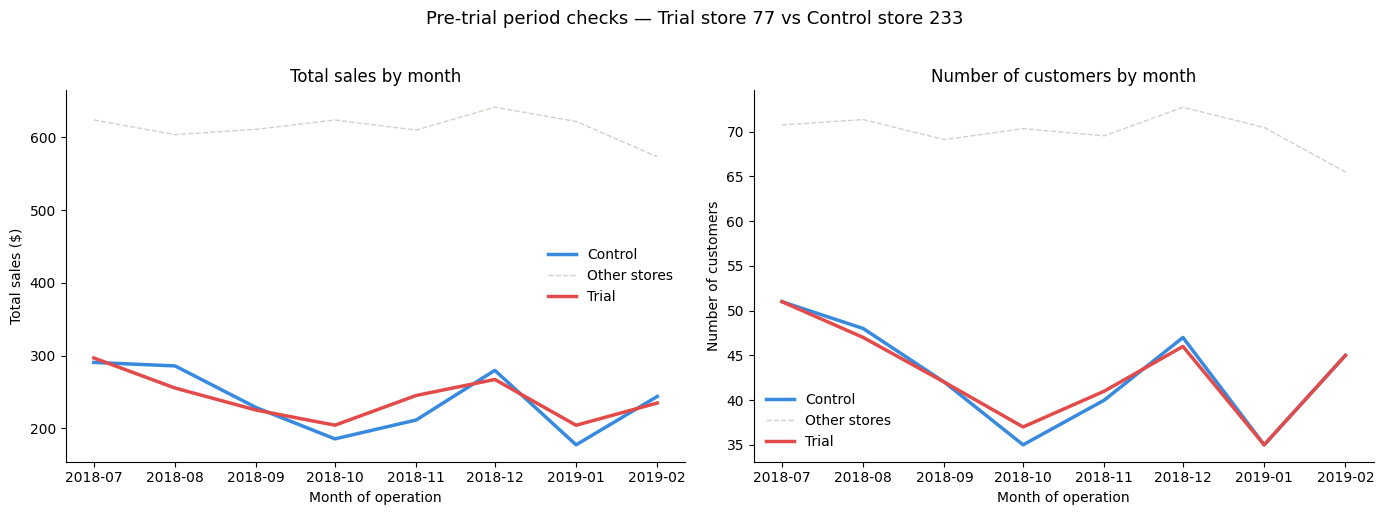

In [11]:
control_store = 233

# ── Tag store types and compute mean per month ────────────────────────────────
def tag_stores(df, trial, control):
    df = df.copy()
    df["Store_type"] = df["STORE_NBR"].apply(
        lambda x: "Trial" if x == trial else ("Control" if x == control else "Other stores")
    )
    return df

# ── Total Sales visual ────────────────────────────────────────────────────────
pastSales = tag_stores(store_monthly, trial_store, control_store)
pastSales = (
    pastSales.groupby(["YEARMONTH", "Store_type"])["TOT_SALES"]
    .mean().reset_index()
)
pastSales["TransactionMonth"] = pd.to_datetime(
    pastSales["YEARMONTH"].astype(str), format="%Y%m"
)
pastSales = pastSales[pastSales["YEARMONTH"] < 201903]

# ── Customer Count visual ─────────────────────────────────────────────────────
pastCustomers = tag_stores(store_monthly, trial_store, control_store)
pastCustomers = (
    pastCustomers.groupby(["YEARMONTH", "Store_type"])["nCustomers"]
    .mean().reset_index()
)
pastCustomers["TransactionMonth"] = pd.to_datetime(
    pastCustomers["YEARMONTH"].astype(str), format="%Y%m"
)
pastCustomers = pastCustomers[pastCustomers["YEARMONTH"] < 201903]

# ── Plot both ─────────────────────────────────────────────────────────────────
colors = {"Trial": "#E24B4A", "Control": "#378ADD", "Other stores": "#D3D1C7"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for store_type, grp in pastSales.groupby("Store_type"):
    ax1.plot(grp["TransactionMonth"], grp["TOT_SALES"],
             label=store_type, color=colors[store_type],
             linewidth=2.5 if store_type != "Other stores" else 1,
             linestyle="-" if store_type != "Other stores" else "--")
ax1.set_title("Total sales by month", fontsize=12)
ax1.set_xlabel("Month of operation")
ax1.set_ylabel("Total sales ($)")
ax1.legend(frameon=False)
ax1.spines[["top", "right"]].set_visible(False)

for store_type, grp in pastCustomers.groupby("Store_type"):
    ax2.plot(grp["TransactionMonth"], grp["nCustomers"],
             label=store_type, color=colors[store_type],
             linewidth=2.5 if store_type != "Other stores" else 1,
             linestyle="-" if store_type != "Other stores" else "--")
ax2.set_title("Number of customers by month", fontsize=12)
ax2.set_xlabel("Month of operation")
ax2.set_ylabel("Number of customers")
ax2.legend(frameon=False)
ax2.spines[["top", "right"]].set_visible(False)

fig.suptitle(f"Pre-trial period checks — Trial store {trial_store} vs Control store {control_store}",
             fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig("pretrial_checks_store77.png", dpi=150, bbox_inches="tight")
plt.show()

### We'll start with scaling the control store's sales to a level similar to control for any differences between the two stores outside of the trial period. 

In [12]:
# ── Confirm pre-trial sums before scaling ─────────────────────────────────────
trial_pretrial_sales   = preTrialMeasures.loc[preTrialMeasures["STORE_NBR"] == trial_store,   "TOT_SALES"].sum()
control_pretrial_sales = preTrialMeasures.loc[preTrialMeasures["STORE_NBR"] == control_store, "TOT_SALES"].sum()

print(f"Trial store {trial_store} pre-trial sales  : ${trial_pretrial_sales:,.2f}")
print(f"Control store {control_store} pre-trial sales: ${control_pretrial_sales:,.2f}")

# ── Scaling factor ─────────────────────────────────────────────────────────────
scalingFactorForControlSales = trial_pretrial_sales / control_pretrial_sales

print(f"Scaling factor: {scalingFactorForControlSales:.4f}")   # expect ~1.024

# ── Apply scaling factor to control store across all months ───────────────────
scaledControlSales = store_monthly[store_monthly["STORE_NBR"] == control_store].copy()
scaledControlSales["controlSales"] = scaledControlSales["TOT_SALES"] * scalingFactorForControlSales

Trial store 77 pre-trial sales  : $1,699.00
Control store 233 pre-trial sales: $1,659.80
Scaling factor: 1.0236


### Now that we have comparable sales figures for the control store, we can calculate the percentage difference between the scaled control sales and the trial store's sales during the trial period.

In [13]:
# ── Percentage difference: trial sales vs scaled control sales ────────────────
trialSales = store_monthly[store_monthly["STORE_NBR"] == trial_store][["YEARMONTH", "TOT_SALES"]].copy()

percentageDiff = trialSales.merge(
    scaledControlSales[["YEARMONTH", "controlSales"]], on="YEARMONTH"
)
percentageDiff["percentageDiff"] = (
    (percentageDiff["TOT_SALES"] - percentageDiff["controlSales"]) /
     percentageDiff["controlSales"] * 100
)

# ── Std dev based on pre-trial period only (null hypothesis baseline) ─────────
stdDev = percentageDiff.loc[
    percentageDiff["YEARMONTH"] < 201902, "percentageDiff"
].std()

print(f"Pre-trial std dev : {stdDev:.4f}")
print(percentageDiff.to_string(index=False))

Pre-trial std dev : 9.9586
 YEARMONTH  TOT_SALES  controlSales  percentageDiff
    201807      296.8    297.565550       -0.257271
    201808      255.5    292.652187      -12.694997
    201809      225.2    233.998916       -3.760238
    201810      204.5    190.085733        7.583035
    201811      245.3    216.597421       13.251579
    201812      267.3    286.408121       -6.671641
    201901      204.4    181.692071       12.498029
    201902      235.0    249.762622       -5.910661
    201903      278.5    203.802205       36.652103
    201904      263.5    162.345704       62.307960
    201905      299.3    352.533799      -15.100339
    201906      264.7    226.219424       17.010288


## Note that there are 8 months in the pre-trial period 
## hence 8 - 1 = 7 degrees of freedomdegreesOfFreedom <- 7 
# We will test with a null hypothesis of there being 0 difference between trial and control stores.

In [14]:
# ── Degrees of freedom: 8 pre-trial months (Jul 2018 – Feb 2019), 8-1 = 7 ────
degreesOfFreedom = 7

# ── Std dev from 8 pre-trial months (includes Feb 2019) ──────────────────────
stdDev = percentageDiff.loc[
    percentageDiff["YEARMONTH"] <= 201902, "percentageDiff"
].std()

# ── T-critical value at 95th percentile ──────────────────────────────────────
tCritical = stats.t.ppf(0.95, df=degreesOfFreedom)

# ── T-values for each month (null hypothesis: mean diff = 0) ─────────────────
# test statistic = (x - 0) / stdDev
percentageDiff["tValue"] = percentageDiff["percentageDiff"] / stdDev
percentageDiff["TransactionMonth"] = pd.to_datetime(
    percentageDiff["YEARMONTH"].astype(str), format="%Y%m"
)

# ── Trial months only with significance flag ──────────────────────────────────
trialResults = percentageDiff[
    percentageDiff["YEARMONTH"].isin([201902, 201903, 201904])
][["TransactionMonth", "YEARMONTH", "TOT_SALES", "controlSales",
   "percentageDiff", "tValue"]].copy()

trialResults["significant"] = trialResults["tValue"].abs() > tCritical

print(f"Std dev (8 pre-trial months) : {stdDev:.4f}")
print(f"T-critical (df=7, 95th pct)  : {tCritical:.4f}")
print()
print(trialResults.to_string(index=False))

Std dev (8 pre-trial months) : 9.5774
T-critical (df=7, 95th pct)  : 1.8946

TransactionMonth  YEARMONTH  TOT_SALES  controlSales  percentageDiff    tValue  significant
      2019-02-01     201902      235.0    249.762622       -5.910661 -0.617147        False
      2019-03-01     201903      278.5    203.802205       36.652103  3.826941         True
      2019-04-01     201904      263.5    162.345704       62.307960  6.505735         True


### Let's create a more visual version of this by plotting the sales of the control store, the sales of the trial stores and the 95th percentile value of sales of the control store.

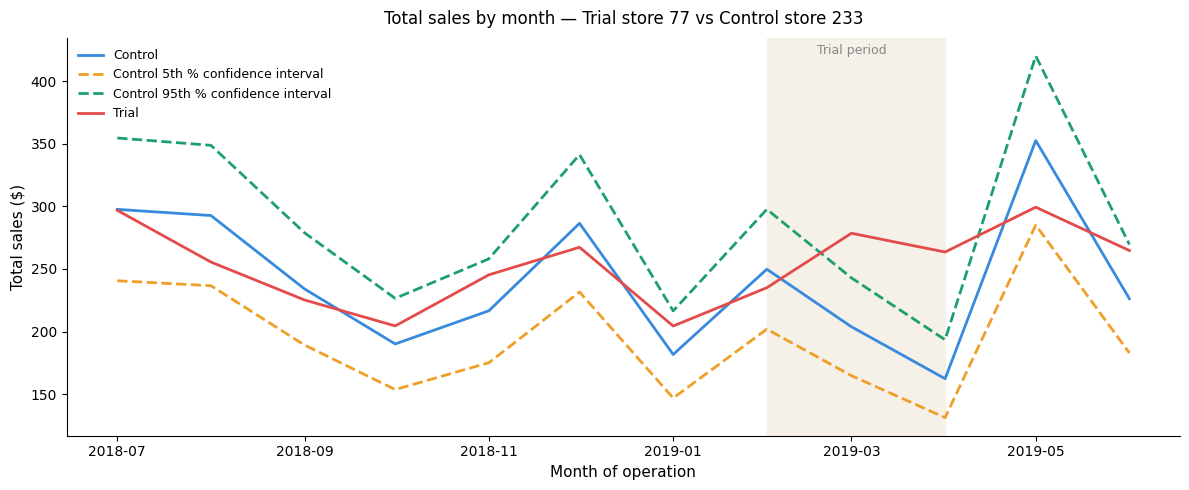

In [15]:
import matplotlib.patches as mpatches

# ── Trial and control store sales ─────────────────────────────────────────────
pastSales_trial = store_monthly[store_monthly["STORE_NBR"] == trial_store][["YEARMONTH","TOT_SALES"]].copy()
pastSales_trial["Store_type"] = "Trial"
pastSales_trial = pastSales_trial.rename(columns={"TOT_SALES":"totSales"})

pastSales_control = scaledControlSales[["YEARMONTH","controlSales"]].copy()
pastSales_control["Store_type"] = "Control"
pastSales_control = pastSales_control.rename(columns={"controlSales":"totSales"})

pastSales = pd.concat([pastSales_trial, pastSales_control], ignore_index=True)
pastSales["TransactionMonth"] = pd.to_datetime(pastSales["YEARMONTH"].astype(str), format="%Y%m")

# ── 95th and 5th percentile confidence bands (± 2 stdDev of % diff) ──────────
pastSales_95 = pastSales_control.copy()
pastSales_95["totSales"]   = pastSales_95["totSales"] * (1 + stdDev/100 * 2)
pastSales_95["Store_type"] = "Control 95th % confidence interval"
pastSales_95["TransactionMonth"] = pd.to_datetime(pastSales_95["YEARMONTH"].astype(str), format="%Y%m")

pastSales_5 = pastSales_control.copy()
pastSales_5["totSales"]   = pastSales_5["totSales"] * (1 - stdDev/100 * 2)
pastSales_5["Store_type"] = "Control 5th % confidence interval"
pastSales_5["TransactionMonth"] = pd.to_datetime(pastSales_5["YEARMONTH"].astype(str), format="%Y%m")

trialAssessment = pd.concat([pastSales, pastSales_95, pastSales_5], ignore_index=True)

# ── Trial period shading (Feb–Apr 2019) ───────────────────────────────────────
trial_months = trialAssessment[
    (trialAssessment["YEARMONTH"] > 201901) &
    (trialAssessment["YEARMONTH"] < 201905)
]["TransactionMonth"]
xmin = trial_months.min()
xmax = trial_months.max()

# ── Plot ──────────────────────────────────────────────────────────────────────
colors = {
    "Trial"                              : "#E24B4A",
    "Control"                            : "#378ADD",
    "Control 95th % confidence interval" : "#1D9E75",
    "Control 5th % confidence interval"  : "#EF9F27",
}
lstyles = {
    "Trial"                              : "-",
    "Control"                            : "-",
    "Control 95th % confidence interval" : "--",
    "Control 5th % confidence interval"  : "--",
}

fig, ax = plt.subplots(figsize=(12, 5))

# Shaded trial period
ax.axvspan(xmin, xmax, color="#f5f0e8", zorder=0, label="_nolegend_")

for store_type, grp in trialAssessment.groupby("Store_type"):
    grp = grp.sort_values("TransactionMonth")
    ax.plot(grp["TransactionMonth"], grp["totSales"],
            label=store_type,
            color=colors[store_type],
            linestyle=lstyles[store_type],
            linewidth=2)

ax.set_xlabel("Month of operation", fontsize=11)
ax.set_ylabel("Total sales ($)", fontsize=11)
ax.set_title(f"Total sales by month — Trial store {trial_store} vs Control store {control_store}",
             fontsize=12, pad=10)
ax.legend(frameon=False, fontsize=9)
ax.spines[["top","right"]].set_visible(False)

# Annotate trial period
ax.text(pd.Timestamp("2019-03-01"), ax.get_ylim()[1]*0.97,
        "Trial period", ha="center", fontsize=9, color="#888")

fig.tight_layout()
fig.savefig("trial_assessment_store77_sales.png", dpi=150, bbox_inches="tight")
plt.show()

### The results show that the trial in store 77 is significantly different to its control store in the trial period as the trial store performance lies outside the 5% to 95% confidence interval of the control store in two of the three trial months.

Scaling factor (customers)  : 1.0034
Std dev (pre-trial)         : 2.5484
T-critical (df=7, 95th pct) : 1.8946

 YEARMONTH  nCustomers  controlCustomers  percentageDiff    tValue
    201807          51         51.171141       -0.334448 -0.131237
    201808          47         48.161074       -2.410814 -0.946001
    201809          42         42.140940       -0.334448 -0.131237
    201810          37         35.117450        5.360726  2.103543
    201811          41         40.134228        2.157191  0.846479
    201812          46         47.157718       -2.454992 -0.963336
    201901          35         35.117450       -0.334448 -0.131237
    201902          45         45.151007       -0.334448 -0.131237
    201903          50         40.134228       24.581940  9.645927
    201904          47         30.100671       56.142698 22.030335
    201905          55         57.191275       -3.831485 -1.503471
    201906          41         41.137584       -0.334448 -0.131237


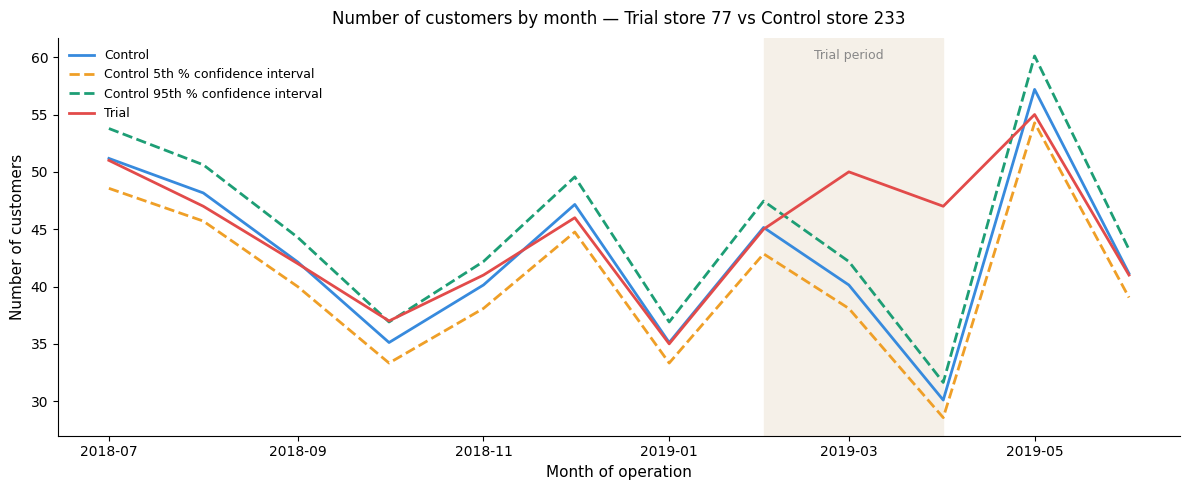

In [16]:
# ── Scaling factor for customer counts ───────────────────────────────────────
scalingFactorForControlCust = (
    preTrialMeasures.loc[preTrialMeasures["STORE_NBR"] == trial_store,   "nCustomers"].sum() /
    preTrialMeasures.loc[preTrialMeasures["STORE_NBR"] == control_store, "nCustomers"].sum()
)

# ── Apply scaling to control store customer counts ────────────────────────────
scaledControlCustomers = store_monthly[store_monthly["STORE_NBR"] == control_store].copy()
scaledControlCustomers["controlCustomers"] = scaledControlCustomers["nCustomers"] * scalingFactorForControlCust
scaledControlCustomers["Store_type"] = "Control"

# ── Percentage difference ─────────────────────────────────────────────────────
trialCustomers = store_monthly[store_monthly["STORE_NBR"] == trial_store][["YEARMONTH","nCustomers"]].copy()

percentageDiffCust = trialCustomers.merge(
    scaledControlCustomers[["YEARMONTH","controlCustomers"]], on="YEARMONTH"
)
percentageDiffCust["percentageDiff"] = (
    (percentageDiffCust["nCustomers"] - percentageDiffCust["controlCustomers"]) /
     percentageDiffCust["controlCustomers"] * 100
)

# ── Std dev and degrees of freedom from 8 pre-trial months ───────────────────
stdDevCust       = percentageDiffCust.loc[percentageDiffCust["YEARMONTH"] <= 201902, "percentageDiff"].std()
degreesOfFreedom = 7
tCritical        = stats.t.ppf(0.95, df=degreesOfFreedom)

# ── T-values for trial months ─────────────────────────────────────────────────
percentageDiffCust["tValue"] = percentageDiffCust["percentageDiff"] / stdDevCust
percentageDiffCust["TransactionMonth"] = pd.to_datetime(
    percentageDiffCust["YEARMONTH"].astype(str), format="%Y%m"
)

print(f"Scaling factor (customers)  : {scalingFactorForControlCust:.4f}")
print(f"Std dev (pre-trial)         : {stdDevCust:.4f}")
print(f"T-critical (df=7, 95th pct) : {tCritical:.4f}")
print()
print(percentageDiffCust[["YEARMONTH","nCustomers","controlCustomers",
                           "percentageDiff","tValue"]].to_string(index=False))

# ── Visual assessment ─────────────────────────────────────────────────────────
pastCust_trial = store_monthly[store_monthly["STORE_NBR"] == trial_store][["YEARMONTH","nCustomers"]].copy()
pastCust_trial["Store_type"] = "Trial"
pastCust_trial = pastCust_trial.rename(columns={"nCustomers":"nCust"})

pastCust_control = scaledControlCustomers[["YEARMONTH","controlCustomers"]].copy()
pastCust_control["Store_type"] = "Control"
pastCust_control = pastCust_control.rename(columns={"controlCustomers":"nCust"})

pastCust = pd.concat([pastCust_trial, pastCust_control], ignore_index=True)
pastCust["TransactionMonth"] = pd.to_datetime(pastCust["YEARMONTH"].astype(str), format="%Y%m")

pastCust_95 = pastCust_control.copy()
pastCust_95["nCust"]      = pastCust_95["nCust"] * (1 + stdDevCust/100 * 2)
pastCust_95["Store_type"] = "Control 95th % confidence interval"
pastCust_95["TransactionMonth"] = pd.to_datetime(pastCust_95["YEARMONTH"].astype(str), format="%Y%m")

pastCust_5 = pastCust_control.copy()
pastCust_5["nCust"]      = pastCust_5["nCust"] * (1 - stdDevCust/100 * 2)
pastCust_5["Store_type"] = "Control 5th % confidence interval"
pastCust_5["TransactionMonth"] = pd.to_datetime(pastCust_5["YEARMONTH"].astype(str), format="%Y%m")

custAssessment = pd.concat([pastCust, pastCust_95, pastCust_5], ignore_index=True)

trial_months  = custAssessment[(custAssessment["YEARMONTH"] > 201901) & (custAssessment["YEARMONTH"] < 201905)]["TransactionMonth"]
xmin, xmax    = trial_months.min(), trial_months.max()

colors  = {"Trial": "#E24B4A", "Control": "#378ADD",
           "Control 95th % confidence interval": "#1D9E75",
           "Control 5th % confidence interval" : "#EF9F27"}
lstyles = {"Trial": "-", "Control": "-",
           "Control 95th % confidence interval": "--",
           "Control 5th % confidence interval" : "--"}

fig, ax = plt.subplots(figsize=(12, 5))
ax.axvspan(xmin, xmax, color="#f5f0e8", zorder=0)

for store_type, grp in custAssessment.groupby("Store_type"):
    grp = grp.sort_values("TransactionMonth")
    ax.plot(grp["TransactionMonth"], grp["nCust"],
            label=store_type, color=colors[store_type],
            linestyle=lstyles[store_type], linewidth=2)

ax.set_xlabel("Month of operation", fontsize=11)
ax.set_ylabel("Number of customers", fontsize=11)
ax.set_title(f"Number of customers by month — Trial store {trial_store} vs Control store {control_store}",
             fontsize=12, pad=10)
ax.text(pd.Timestamp("2019-03-01"), ax.get_ylim()[1]*0.97,
        "Trial period", ha="center", fontsize=9, color="#888")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig("trial_assessment_store77_customers.png", dpi=150, bbox_inches="tight")
plt.show()

# Trial store 86

In [17]:
trial_store  = 86
corr_weight  = 0.5

corr_nSales     = calculateCorrelation(preTrialMeasures, "TOT_SALES",  trial_store)
corr_nCustomers = calculateCorrelation(preTrialMeasures, "nCustomers", trial_store)
mag_nSales      = calculateMagnitudeDistance(preTrialMeasures, "TOT_SALES",  trial_store)
mag_nCustomers  = calculateMagnitudeDistance(preTrialMeasures, "nCustomers", trial_store)

score_nSales = corr_nSales.merge(mag_nSales, on=["Store1","Store2"])
score_nSales["scoreNSales"] = corr_weight * score_nSales["corr_measure"] + (1-corr_weight) * score_nSales["mag_measure"]

score_nCustomers = corr_nCustomers.merge(mag_nCustomers, on=["Store1","Store2"])
score_nCustomers["scoreNCust"] = corr_weight * score_nCustomers["corr_measure"] + (1-corr_weight) * score_nCustomers["mag_measure"]

score_Control = score_nSales[["Store1","Store2","scoreNSales"]].merge(
    score_nCustomers[["Store1","Store2","scoreNCust"]], on=["Store1","Store2"])
score_Control["finalControlScore"] = 0.5 * score_Control["scoreNSales"] + 0.5 * score_Control["scoreNCust"]
score_Control = score_Control.sort_values("finalControlScore", ascending=False).reset_index(drop=True)

# Skip rank 1 (store itself scores 1.0), take rank 2 — mirrors R's [order(-finalControlScore)][2]
control_store = int(score_Control[score_Control["Store2"] != trial_store].iloc[0]["Store2"])
print(f"Control store for trial store {trial_store}: {control_store}") 

Control store for trial store 86: 155


###  Pre-trial visual check (sales and customers):

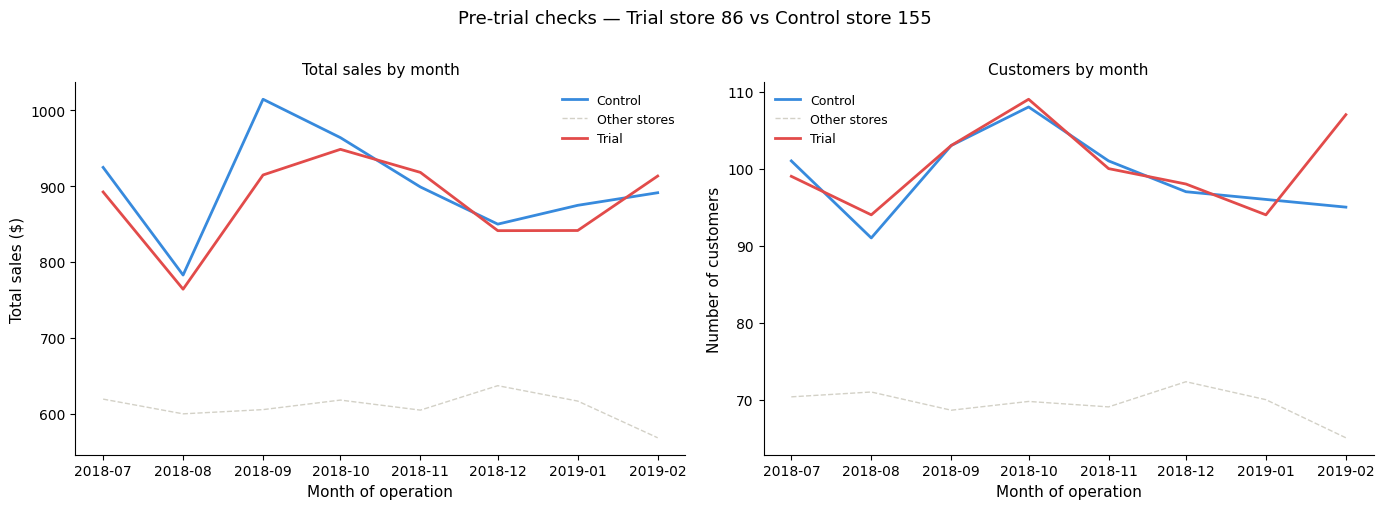

In [21]:
colors  = {"Trial": "#E24B4A", "Control": "#378ADD", "Other stores": "#D3D1C7"}
lstyles = {"Trial": "-", "Control": "-", "Other stores": "--"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, ylabel, title_ in [
    (ax1, "TOT_SALES",  "Total sales ($)",      "Total sales by month"),
    (ax2, "nCustomers", "Number of customers",  "Customers by month")
]:
    plot_df = store_monthly[store_monthly["YEARMONTH"] < 201903].copy()
    plot_df["Store_type"] = plot_df["STORE_NBR"].apply(
        lambda x: "Trial" if x == trial_store else ("Control" if x == control_store else "Other stores")
    )
    plot_df = (
        plot_df.groupby(["YEARMONTH", "Store_type"])[metric]
        .mean().reset_index()
    )
    plot_df["TransactionMonth"] = pd.to_datetime(plot_df["YEARMONTH"].astype(str), format="%Y%m")

    for st, grp in plot_df.groupby("Store_type"):
        grp = grp.sort_values("TransactionMonth")
        ax.plot(grp["TransactionMonth"], grp[metric],
                label=st, color=colors[st],
                linestyle=lstyles[st],
                linewidth=2 if st != "Other stores" else 1)

    ax.set_xlabel("Month of operation", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title_, fontsize=11)
    ax.legend(frameon=False, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(f"Pre-trial checks — Trial store {trial_store} vs Control store {control_store}",
             fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(f"pretrial_checks_store{trial_store}.png", dpi=150, bbox_inches="tight")
plt.show()

###  Pre-trial visual check (sales and customers):

In [22]:
# ── Scaling factor ────────────────────────────────────────────────────────────
scalingFactorForControlSales = (
    preTrialMeasures.loc[preTrialMeasures["STORE_NBR"] == trial_store,   "TOT_SALES"].sum() /
    preTrialMeasures.loc[preTrialMeasures["STORE_NBR"] == control_store, "TOT_SALES"].sum()
)

# ── Apply scaling ─────────────────────────────────────────────────────────────
scaledControlSales = store_monthly[store_monthly["STORE_NBR"] == control_store].copy()
scaledControlSales["controlSales"] = scaledControlSales["TOT_SALES"] * scalingFactorForControlSales

# ── Percentage difference ─────────────────────────────────────────────────────
trialSales = store_monthly[store_monthly["STORE_NBR"] == trial_store][["YEARMONTH", "TOT_SALES"]].copy()

percentageDiff = trialSales.merge(
    scaledControlSales[["YEARMONTH", "controlSales"]], on="YEARMONTH"
)
percentageDiff["percentageDiff"] = (
    (percentageDiff["TOT_SALES"] - percentageDiff["controlSales"]) /
     percentageDiff["controlSales"] * 100
)

# ── Std dev, t-values ─────────────────────────────────────────────────────────
stdDevSales      = percentageDiff.loc[percentageDiff["YEARMONTH"] <= 201902, "percentageDiff"].std()
degreesOfFreedom = 7
tCritical        = stats.t.ppf(0.95, df=degreesOfFreedom)
percentageDiff["tValue"] = percentageDiff["percentageDiff"] / stdDevSales

print(f"Scaling factor : {scalingFactorForControlSales:.4f}")
print(f"Std dev        : {stdDevSales:.4f}")
print(f"T-critical     : {tCritical:.4f}")
print()
print(percentageDiff[["YEARMONTH","TOT_SALES","controlSales","percentageDiff","tValue"]].to_string(index=False))

Scaling factor : 0.9701
Std dev        : 3.9924
T-critical     : 1.8946

 YEARMONTH  TOT_SALES  controlSales  percentageDiff    tValue
    201807     892.20    896.922236       -0.526493 -0.131872
    201808     764.05    759.269991        0.629553  0.157686
    201809     914.60    984.034086       -7.056065 -1.767355
    201810     948.40    934.948790        1.438711  0.360359
    201811     918.00    871.894555        5.287961  1.324492
    201812     841.20    824.361363        2.042628  0.511624
    201901     841.40    848.418979       -0.827301 -0.207217
    201902     913.20    864.522060        5.630619  1.410319
    201903    1026.80    780.320405       31.586973  7.911690
    201904     848.20    819.317024        3.525250  0.882981
    201905     889.30    895.224622       -0.661803 -0.165764
    201906     838.00    831.539845        0.776891  0.194590


### sales assessment plot with confidence bands:

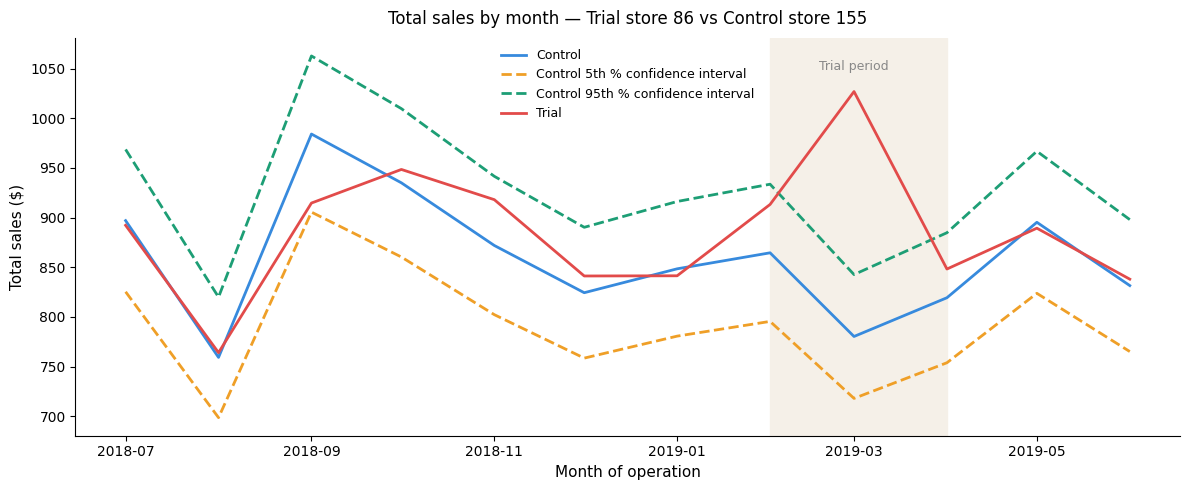

In [23]:
# ── Build plot data ───────────────────────────────────────────────────────────
pastSales_trial = store_monthly[store_monthly["STORE_NBR"] == trial_store][["YEARMONTH","TOT_SALES"]].copy()
pastSales_trial["Store_type"] = "Trial"
pastSales_trial = pastSales_trial.rename(columns={"TOT_SALES":"totSales"})

pastSales_control = scaledControlSales[["YEARMONTH","controlSales"]].copy()
pastSales_control["Store_type"] = "Control"
pastSales_control = pastSales_control.rename(columns={"controlSales":"totSales"})

pastSales_95 = pastSales_control.copy()
pastSales_95["totSales"]   = pastSales_95["totSales"] * (1 + stdDevSales/100 * 2)
pastSales_95["Store_type"] = "Control 95th % confidence interval"

pastSales_5 = pastSales_control.copy()
pastSales_5["totSales"]    = pastSales_5["totSales"] * (1 - stdDevSales/100 * 2)
pastSales_5["Store_type"]  = "Control 5th % confidence interval"

trialAssessment = pd.concat([pastSales_trial, pastSales_control,
                              pastSales_95, pastSales_5], ignore_index=True)
trialAssessment["TransactionMonth"] = pd.to_datetime(
    trialAssessment["YEARMONTH"].astype(str), format="%Y%m"
)

# ── Plot ──────────────────────────────────────────────────────────────────────
colors  = {"Trial": "#E24B4A", "Control": "#378ADD",
           "Control 95th % confidence interval": "#1D9E75",
           "Control 5th % confidence interval" : "#EF9F27"}
lstyles = {"Trial": "-", "Control": "-",
           "Control 95th % confidence interval": "--",
           "Control 5th % confidence interval" : "--"}

trial_months = trialAssessment[
    (trialAssessment["YEARMONTH"] > 201901) &
    (trialAssessment["YEARMONTH"] < 201905)
]["TransactionMonth"]
xmin, xmax = trial_months.min(), trial_months.max()

fig, ax = plt.subplots(figsize=(12, 5))
ax.axvspan(xmin, xmax, color="#f5f0e8", zorder=0)

for st, grp in trialAssessment.groupby("Store_type"):
    grp = grp.sort_values("TransactionMonth")
    ax.plot(grp["TransactionMonth"], grp["totSales"],
            label=st, color=colors[st],
            linestyle=lstyles[st], linewidth=2)

ax.set_xlabel("Month of operation", fontsize=11)
ax.set_ylabel("Total sales ($)", fontsize=11)
ax.set_title(f"Total sales by month — Trial store {trial_store} vs Control store {control_store}",
             fontsize=12, pad=10)
ax.text(pd.Timestamp("2019-03-01"), ax.get_ylim()[1]*0.97,
        "Trial period", ha="center", fontsize=9, color="#888")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(f"trial_sales_store{trial_store}.png", dpi=150, bbox_inches="tight")
plt.show()

###  Scale control customers and calculate percentage difference

In [24]:
# ── Scaling factor ────────────────────────────────────────────────────────────
scalingFactorForControlCust = (
    preTrialMeasures.loc[preTrialMeasures["STORE_NBR"] == trial_store,   "nCustomers"].sum() /
    preTrialMeasures.loc[preTrialMeasures["STORE_NBR"] == control_store, "nCustomers"].sum()
)

# ── Apply scaling ─────────────────────────────────────────────────────────────
scaledControlCust = store_monthly[store_monthly["STORE_NBR"] == control_store].copy()
scaledControlCust["controlCustomers"] = scaledControlCust["nCustomers"] * scalingFactorForControlCust

# ── Percentage difference ─────────────────────────────────────────────────────
trialCust = store_monthly[store_monthly["STORE_NBR"] == trial_store][["YEARMONTH","nCustomers"]].copy()

percentageDiffCust = trialCust.merge(
    scaledControlCust[["YEARMONTH","controlCustomers"]], on="YEARMONTH"
)
percentageDiffCust["percentageDiff"] = (
    (percentageDiffCust["nCustomers"] - percentageDiffCust["controlCustomers"]) /
     percentageDiffCust["controlCustomers"] * 100
)

# ── Std dev, t-values ─────────────────────────────────────────────────────────
stdDevCust               = percentageDiffCust.loc[percentageDiffCust["YEARMONTH"] <= 201902, "percentageDiff"].std()
percentageDiffCust["tValue"] = percentageDiffCust["percentageDiff"] / stdDevCust

print(f"Scaling factor : {scalingFactorForControlCust:.4f}")
print(f"Std dev        : {stdDevCust:.4f}")
print(f"T-critical     : {tCritical:.4f}")
print()
print(percentageDiffCust[["YEARMONTH","nCustomers","controlCustomers","percentageDiff","tValue"]].to_string(index=False))

Scaling factor : 1.0000
Std dev        : 4.7959
T-critical     : 1.8946

 YEARMONTH  nCustomers  controlCustomers  percentageDiff    tValue
    201807          99             101.0       -1.980198 -0.412892
    201808          94              91.0        3.296703  0.687397
    201809         103             103.0        0.000000  0.000000
    201810         109             108.0        0.925926  0.193065
    201811         100             101.0       -0.990099 -0.206446
    201812          98              97.0        1.030928  0.214959
    201901          94              96.0       -2.083333 -0.434397
    201902         107              95.0       12.631579  2.633817
    201903         115              94.0       22.340426  4.658214
    201904         105              99.0        6.060606  1.263700
    201905         104             106.0       -1.886792 -0.393416
    201906          98              95.0        3.157895  0.658454


### Customer uplift is significant in Feb (t=2.63) and Mar (t=4.66). Step 7 — customer assessment plot with confidence bands:


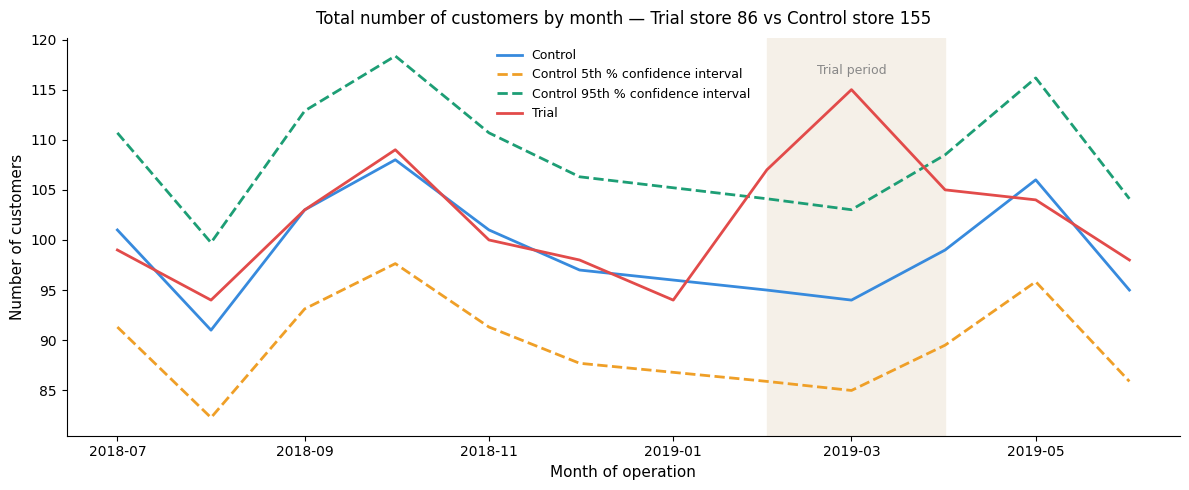

In [25]:
# ── Build plot data ───────────────────────────────────────────────────────────
pastCust_trial = store_monthly[store_monthly["STORE_NBR"] == trial_store][["YEARMONTH","nCustomers"]].copy()
pastCust_trial["Store_type"] = "Trial"
pastCust_trial = pastCust_trial.rename(columns={"nCustomers":"nCusts"})

pastCust_control = scaledControlCust[["YEARMONTH","controlCustomers"]].copy()
pastCust_control["Store_type"] = "Control"
pastCust_control = pastCust_control.rename(columns={"controlCustomers":"nCusts"})

pastCust_95 = pastCust_control.copy()
pastCust_95["nCusts"]     = pastCust_95["nCusts"] * (1 + stdDevCust/100 * 2)
pastCust_95["Store_type"] = "Control 95th % confidence interval"

pastCust_5 = pastCust_control.copy()
pastCust_5["nCusts"]      = pastCust_5["nCusts"] * (1 - stdDevCust/100 * 2)
pastCust_5["Store_type"]  = "Control 5th % confidence interval"

custAssessment = pd.concat([pastCust_trial, pastCust_control,
                             pastCust_95, pastCust_5], ignore_index=True)
custAssessment["TransactionMonth"] = pd.to_datetime(
    custAssessment["YEARMONTH"].astype(str), format="%Y%m"
)

# ── Plot ──────────────────────────────────────────────────────────────────────
colors  = {"Trial": "#E24B4A", "Control": "#378ADD",
           "Control 95th % confidence interval": "#1D9E75",
           "Control 5th % confidence interval" : "#EF9F27"}
lstyles = {"Trial": "-", "Control": "-",
           "Control 95th % confidence interval": "--",
           "Control 5th % confidence interval" : "--"}

trial_months = custAssessment[
    (custAssessment["YEARMONTH"] > 201901) &
    (custAssessment["YEARMONTH"] < 201905)
]["TransactionMonth"]
xmin, xmax = trial_months.min(), trial_months.max()

fig, ax = plt.subplots(figsize=(12, 5))
ax.axvspan(xmin, xmax, color="#f5f0e8", zorder=0)

for st, grp in custAssessment.groupby("Store_type"):
    grp = grp.sort_values("TransactionMonth")
    ax.plot(grp["TransactionMonth"], grp["nCusts"],
            label=st, color=colors[st],
            linestyle=lstyles[st], linewidth=2)

ax.set_xlabel("Month of operation", fontsize=11)
ax.set_ylabel("Number of customers", fontsize=11)
ax.set_title(f"Total number of customers by month — Trial store {trial_store} vs Control store {control_store}",
             fontsize=12, pad=10)
ax.text(pd.Timestamp("2019-03-01"), ax.get_ylim()[1]*0.97,
        "Trial period", ha="center", fontsize=9, color="#888")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(f"trial_customers_store{trial_store}.png", dpi=150, bbox_inches="tight")
plt.show()

### Control store selection for store 88